In [1]:
import numpy as np


In [2]:
def pds_awgn(N, fs, potencia_W):
    tt = np.arange(start = 0, step = 1/fs, stop = N*(1/fs))
    desvio_std = np.sqrt(potencia_W)
    media = 0
    xx = np.random.normal(loc=media, scale=desvio_std, size=N)
    return xx, tt

def pds_sen_ruidosa(nn = 1000, fs = 1000, freq = 1, Amax = np.sqrt(2), dc = 0, phase = 0, SNR_db = "inf"):
    tt = np.arange(start = 0, step = 1/fs, stop = nn*(1/fs))
    x1 = dc + Amax * np.sin(2*np.pi * freq * tt + phase)

    if SNR_db != "inf" and (type(SNR_db) == float or type(SNR_db) == int):
        pot_senal = 10*np.log10((Amax**2) / 2)
        pot_ruido = pot_senal - SNR_db
        x2, tt = pds_awgn(nn, fs, potencia_W = 10**(pot_ruido/10))
        xx = x1 + x2
    else:
        xx = x1

    return xx, tt


N = 10
fs = 10
xx, tt = pds_sen_ruidosa(nn = N, fs = fs, freq = 1, Amax = 1, dc = 0, phase = 0, SNR_db = "inf")

In [3]:
def pds_dft(xx):
    N = len(xx)
    xn = np.array(xx).reshape((1, N))
    matriz_e = np.matrix([[np.exp(-1j * 2 * np.pi * n * k / N) for k in range(N)] for n in range(N)])
    xk = np.dot(xn, matriz_e)
    xk = np.asarray(xk).squeeze()
    return xk

xk = pds_dft(xx)

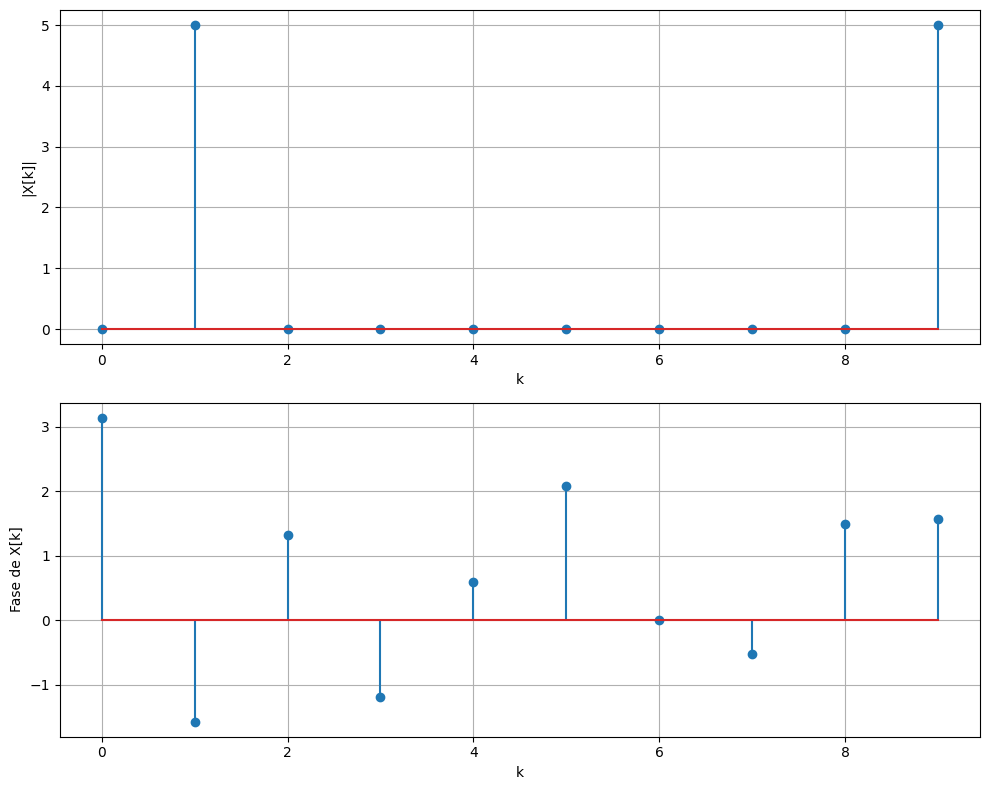

In [4]:
import matplotlib.pyplot as plt

figure, axs = plt.subplots(2, 1, figsize=(10, 8))
axs[0].stem(np.arange(N), np.abs(xk))
axs[0].set_xlabel('k')
axs[0].set_ylabel('|X[k]|')
axs[0].grid(True)

axs[1].stem(np.arange(N), np.angle(xk))
axs[1].set_xlabel('k')
axs[1].set_ylabel('Fase de X[k]')
axs[1].grid(True)

plt.tight_layout()
plt.show()

Experiencias:

Agregar parte real y parte imaginaria en funcion de K. Ver que el pi sobre dos sale del arcotangente de eso

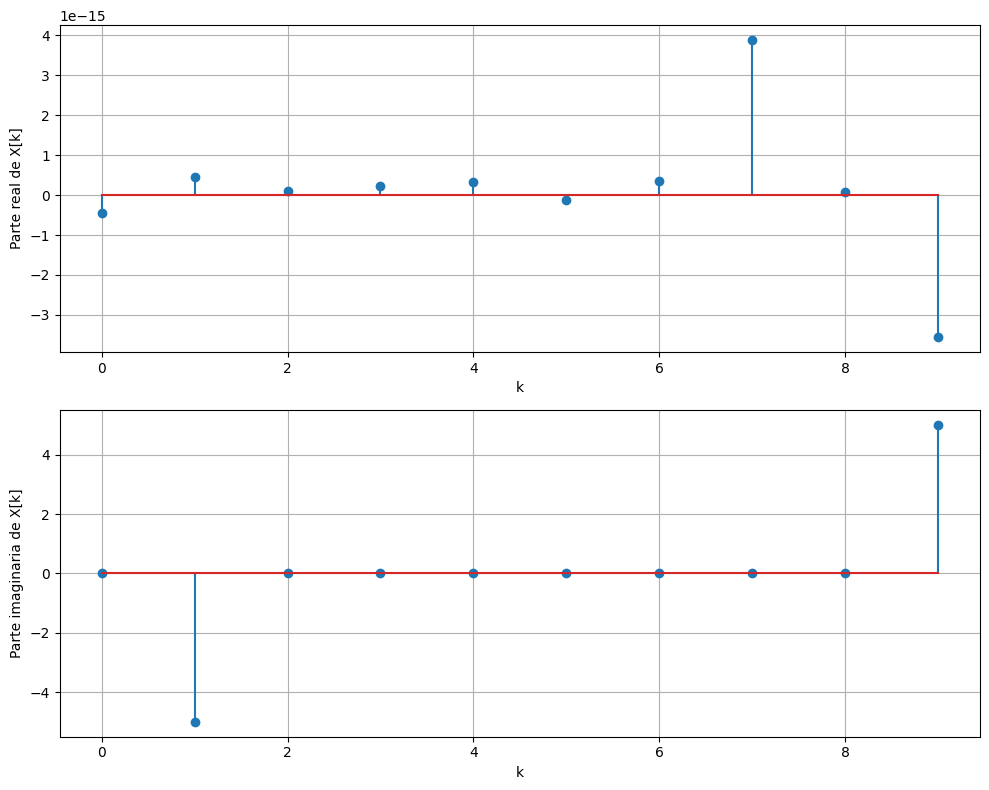

In [5]:
figure, axs = plt.subplots(2, 1, figsize=(10, 8))
axs[0].stem(np.arange(N), np.real(xk))
axs[0].set_xlabel('k')
axs[0].set_ylabel('Parte real de X[k]')
axs[0].grid(True)

axs[1].stem(np.arange(N), np.imag(xk))
axs[1].set_xlabel('k')
axs[1].set_ylabel('Parte imaginaria de X[k]')
axs[1].grid(True)

plt.tight_layout()
plt.show()

Comparo con FFT

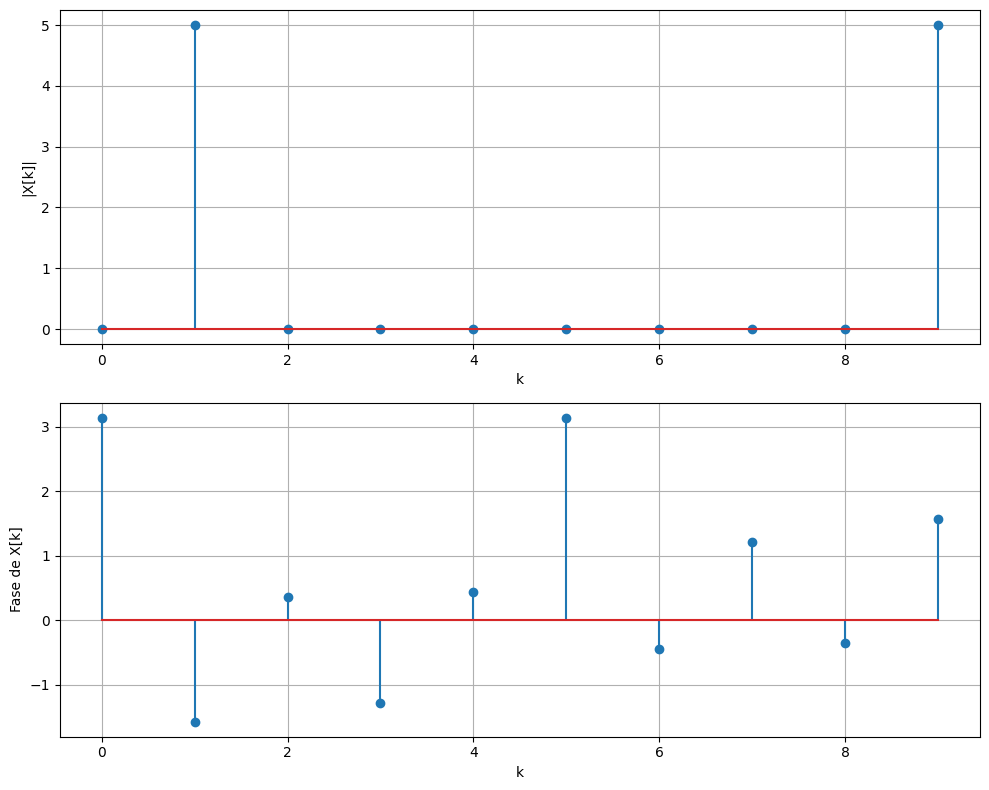

In [6]:
xk2 = np.fft.fft(xx)

figure, axs = plt.subplots(2, 1, figsize=(10, 8))
axs[0].stem(np.arange(N), np.abs(xk2))
axs[0].set_xlabel('k')
axs[0].set_ylabel('|X[k]|')
axs[0].grid(True)

axs[1].stem(np.arange(N), np.angle(xk2))
axs[1].set_xlabel('k')
axs[1].set_ylabel('Fase de X[k]')
axs[1].grid(True)

plt.tight_layout()
plt.show()

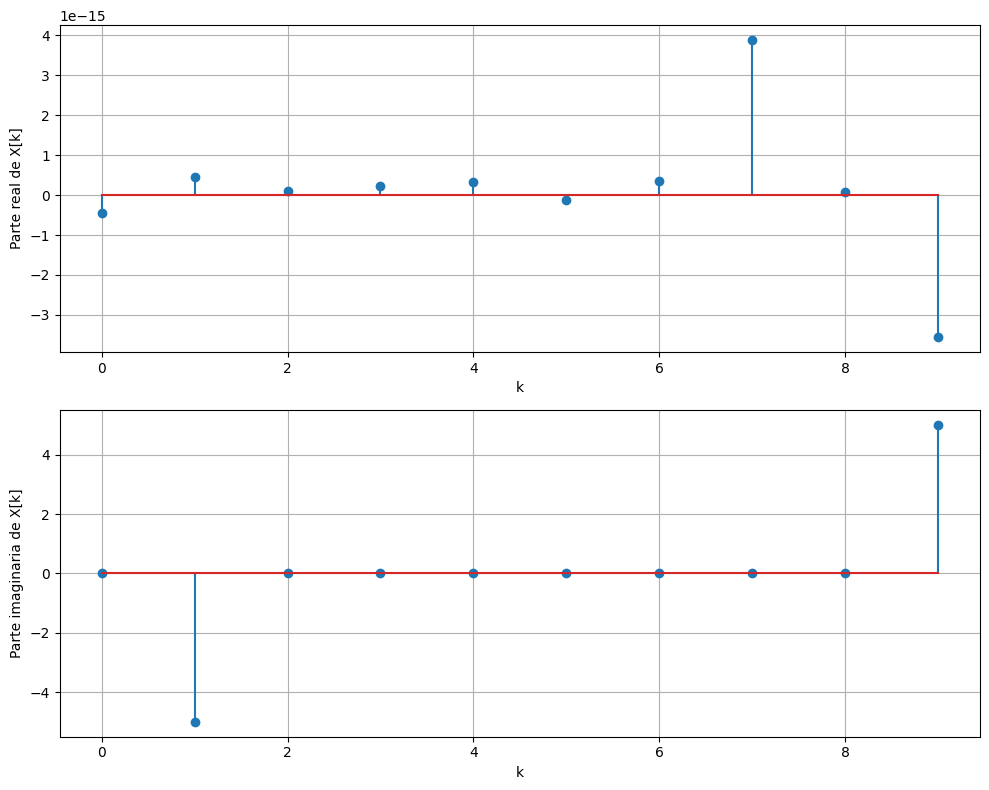

In [7]:
figure, axs = plt.subplots(2, 1, figsize=(10, 8))
axs[0].stem(np.arange(N), np.real(xk))
axs[0].set_xlabel('k')
axs[0].set_ylabel('Parte real de X[k]')
axs[0].grid(True)

axs[1].stem(np.arange(N), np.imag(xk))
axs[1].set_xlabel('k')
axs[1].set_ylabel('Parte imaginaria de X[k]')
axs[1].grid(True)

plt.tight_layout()
plt.show()

Probar otras señales paara q haya mas espectro

Senoidal desplazada
1- Coseno

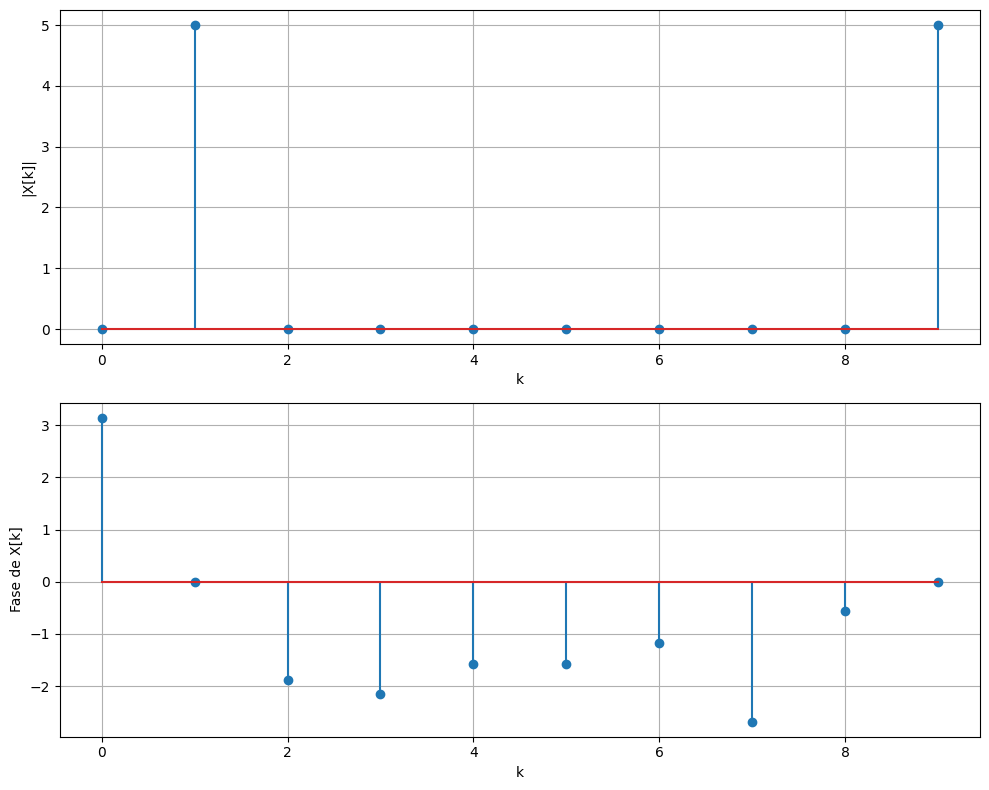

In [8]:
xx, tt = pds_sen_ruidosa(nn = N, fs = fs, freq = 1, Amax = 1, dc = 0, phase = np.pi/2, SNR_db = "inf")

xk = pds_dft(xx)

figure, axs = plt.subplots(2, 1, figsize=(10, 8))
axs[0].stem(np.arange(N), np.abs(xk))
axs[0].set_xlabel('k')
axs[0].set_ylabel('|X[k]|')
axs[0].grid(True)

axs[1].stem(np.arange(N), np.angle(xk))
axs[1].set_xlabel('k')
axs[1].set_ylabel('Fase de X[k]')
axs[1].grid(True)

plt.tight_layout()
plt.show()

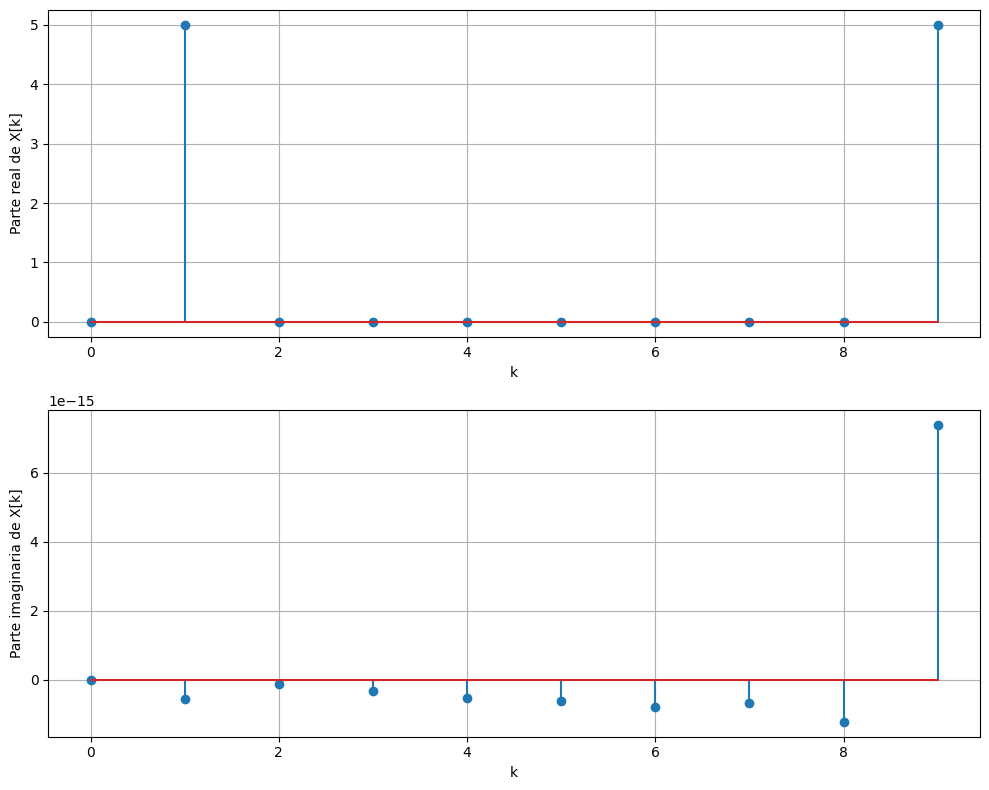

In [9]:
figure, axs = plt.subplots(2, 1, figsize=(10, 8))
axs[0].stem(np.arange(N), np.real(xk))
axs[0].set_xlabel('k')
axs[0].set_ylabel('Parte real de X[k]')
axs[0].grid(True)

axs[1].stem(np.arange(N), np.imag(xk))
axs[1].set_xlabel('k')
axs[1].set_ylabel('Parte imaginaria de X[k]')
axs[1].grid(True)

plt.tight_layout()
plt.show()

Senoidal desplazada

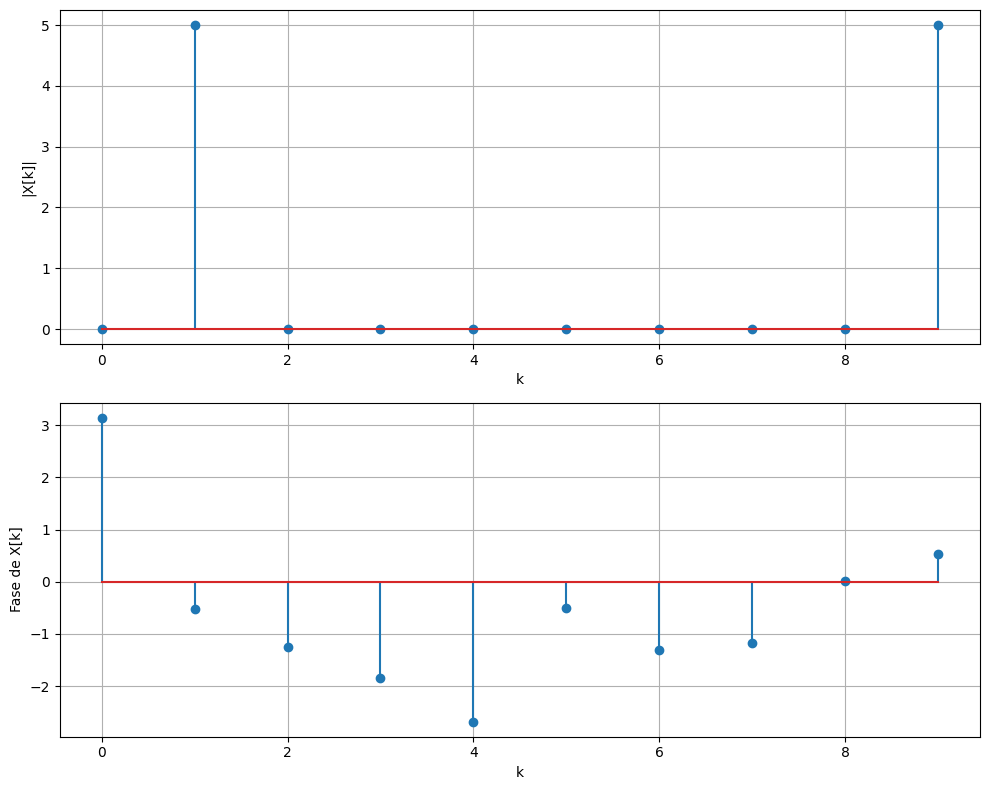

In [10]:
xx, tt = pds_sen_ruidosa(nn = N, fs = fs, freq = 1, Amax = 1, dc = 0, phase = np.pi/3, SNR_db = "inf")

xk = pds_dft(xx)

figure, axs = plt.subplots(2, 1, figsize=(10, 8))
axs[0].stem(np.arange(N), np.abs(xk))
axs[0].set_xlabel('k')
axs[0].set_ylabel('|X[k]|')
axs[0].grid(True)

axs[1].stem(np.arange(N), np.angle(xk))
axs[1].set_xlabel('k')
axs[1].set_ylabel('Fase de X[k]')
axs[1].grid(True)

plt.tight_layout()
plt.show()

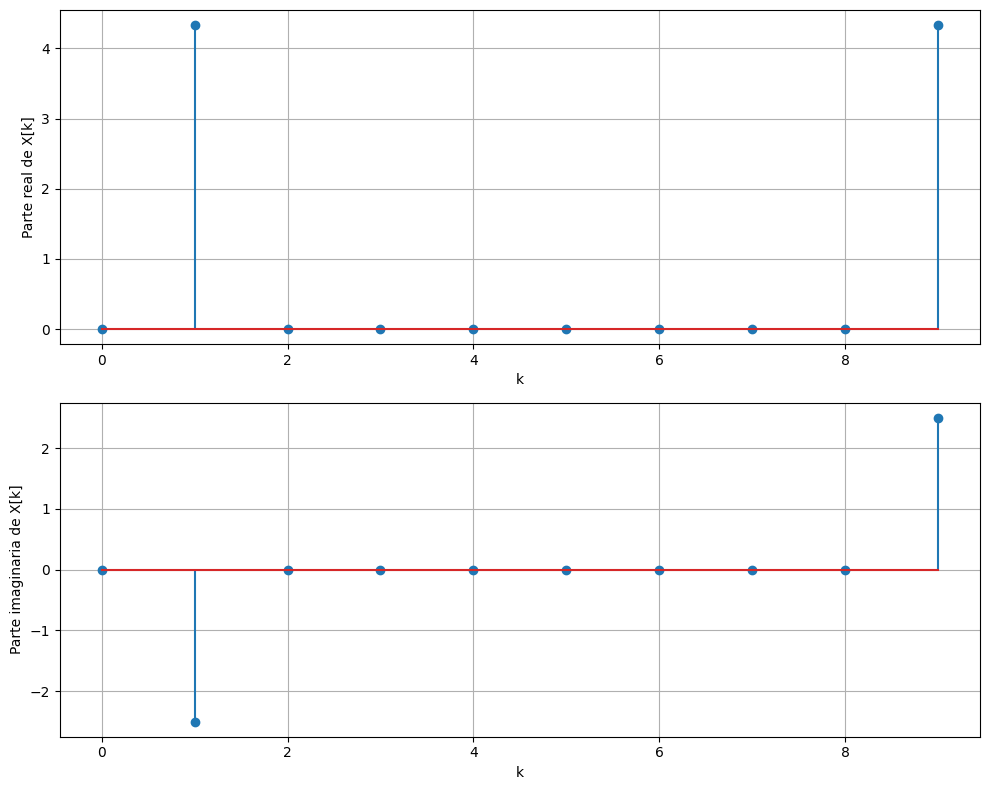

In [11]:
figure, axs = plt.subplots(2, 1, figsize=(10, 8))
axs[0].stem(np.arange(N), np.real(xk))
axs[0].set_xlabel('k')
axs[0].set_ylabel('Parte real de X[k]')
axs[0].grid(True)

axs[1].stem(np.arange(N), np.imag(xk))
axs[1].set_xlabel('k')
axs[1].set_ylabel('Parte imaginaria de X[k]')
axs[1].grid(True)

plt.tight_layout()
plt.show()

Diferencias de tiempo entre DFT y FFT

In [20]:
import timeit

xx = np.random.rand(16)


t_dft = timeit.timeit(lambda: pds_dft(xx), number=200)
t_fft = timeit.timeit(lambda: np.fft.fft(xx), number=200)

print(f"Tiempo DFT: {t_dft:.6f} segundos")
print(f"Tiempo FFT: {t_fft:.6f} segundos")
print(f"Relación de tiempos (DFT/FFT): {t_dft / t_fft:.2f}")

Tiempo DFT: 0.050475 segundos
Tiempo FFT: 0.002563 segundos
Relación de tiempos (DFT/FFT): 19.69


Capitulo 10 y 11 de holton para comparar